# The exposure merge: did the monsoon sale reach who we think?

**Week 2, Thursday. Round 2 of 3.** The question: which customers did August's monsoon sale
reach, and how many of them bought?

> **The client's ask.** The marketing lead, owner of acquisition and campaigns: "Put the
> monsoon sale on the customer table. I want to see, per segment, who it reached and how many
> of them bought, because I am asking for the same budget in November."

> **Kavya's review.** "A merge is a join, so I want Tuesday's habit: the row count before and
> after, and the spend total before and after. If either moves, the merge is wrong until
> you can say why."

Round 1 built one row per customer: 340 rows, spend adding to Rs 19,84,00,000, recency
measured from 28 September. This round attaches a second source to it.

**Setup.** The warehouse tables, round 1's table rebuilt in a few lines, and the exposure
feed. The feed arrives as a file from the campaign platform, one row per customer the sale
reached, or so the platform says.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
import pandas as pd

ENG = kit.engine()
orders = pd.read_sql(
    "SELECT order_id, customer_id, order_date, quarter, channel, amount, status FROM orders",
    ENG, parse_dates=["order_date"])
customers = pd.read_sql("SELECT customer_id, segment, city FROM customers", ENG)
print(f"{len(orders):,} orders and {len(customers):,} customers read from the warehouse")

AS_OF = orders["order_date"].max()
rfm = (orders.groupby("customer_id")
             .agg(last_order=("order_date", "max"), frequency=("order_id", "count"),
                  monetary=("amount", "sum"))
             .reset_index())
table = customers.merge(rfm, on="customer_id", how="left", validate="one_to_one")
table = table.assign(frequency=table["frequency"].fillna(0).astype("int64"),
                     monetary=table["monetary"].fillna(0),
                     recency_days=(AS_OF - table["last_order"]).dt.days)
print(f"round 1's table: {len(table)} customers, as of {AS_OF.date()}")

exposure = pd.read_csv(kit.data_dir() / "C2_W02_D04_exposure_STUDENT.csv", parse_dates=["exposed_date"])
print("exposure feed columns:", list(exposure.columns))

1,000 orders and 340 customers read from the warehouse
round 1's table: 340 customers, as of 2026-09-28
exposure feed columns: ['customer_id', 'campaign_id', 'exposed_date']


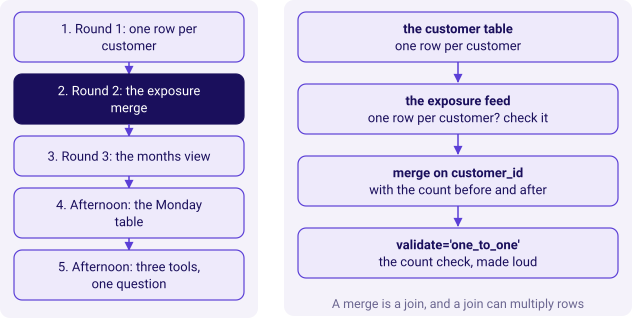

In [2]:
kit.side_by_side(
    kit.ladder(['Round 1: one row per customer', 'Round 2: the exposure merge', 'Round 3: the months view', 'Afternoon: the Monday table', 'Afternoon: three tools, one question'], lit=1, show=False),
    kit.vflow(["the customer table\none row per customer",
               "the exposure feed\none row per customer? check it",
               "merge on customer_id\nwith the count before and after",
               "validate='one_to_one'\nthe count check, made loud"],
              title="A merge is a join, and a join can multiply rows", show=False),
)

## 1. A merge is a join, with the same four shapes

| SQL on Tuesday | pandas today | keeps |
|---|---|---|
| `INNER JOIN` | `merge(how="inner")`, the default | only keys on both sides |
| `LEFT JOIN` | `merge(how="left")` | every row of the left table |
| `RIGHT JOIN` | `merge(how="right")` | every row of the right table |
| `FULL OUTER JOIN` | `merge(how="outer")` | every key from either side |

The customer table is the spine, so the merge is `how="left"`: every customer stays, and the
feed adds a date where it has one.

**Predict before you run.** `merge` with no `how` keeps which customers?
a) every customer; b) only customers in the feed, since the default is inner; c) every feed
row, even unknown customers; d) none, because `how` is required.

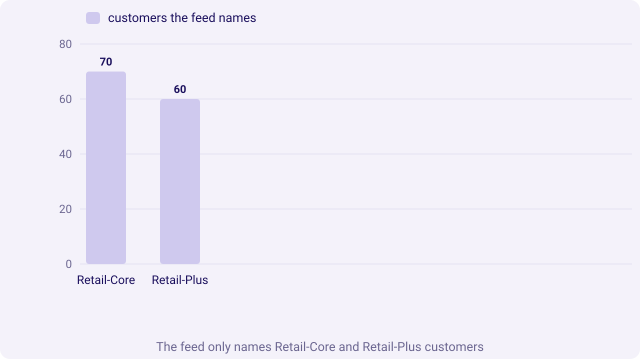

In [3]:
inner = table.merge(exposure[["customer_id"]].drop_duplicates(), on="customer_id")
reached = exposure.groupby(
    exposure["customer_id"].map(table.set_index("customer_id")["segment"]))["customer_id"].nunique()
kit.columns(reached.index.tolist(), [("customers the feed names", reached.tolist())],
            width=640, title="The feed only names Retail-Core and Retail-Plus customers")
kit.check("the default merge is inner: only customers named in the feed survive",
          inner["customer_id"].nunique() == exposure["customer_id"].nunique(),
          f"{inner['customer_id'].nunique()} of {len(table)} customers")
kit.check("every customer the feed names is in the customer table",
          exposure["customer_id"].isin(table["customer_id"]).all())

**What happened.** The answer is b. `merge` defaults to an inner join, which silently drops
every customer the sale did not reach, and the unreached are exactly the comparison group
Marketing needs. Write `how=` every time, so the reader of the code knows which rows
survive.

## 2. The trap: a merge that doubles a customer's spend

The mechanism first, on four invented customers so it can be seen whole. **These records are
invented for the mechanism; they are not Kalpa's.** The campaign platform sends its feed in
batches, and when a batch is re-sent, a customer arrives twice.

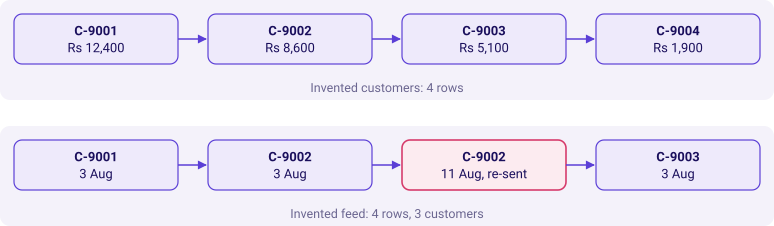

In [4]:
small = pd.DataFrame({"customer_id": ["C-9001", "C-9002", "C-9003", "C-9004"],
                      "segment": ["Retail-Plus", "Retail-Core", "Retail-Plus", "Student"],
                      "monetary": [12400, 8600, 5100, 1900]})
small_feed = pd.DataFrame({"customer_id": ["C-9001", "C-9002", "C-9002", "C-9003"],
                           "exposed_date": pd.to_datetime(["2026-08-03", "2026-08-03",
                                                           "2026-08-11", "2026-08-03"])})
kit.side_by_side(
    kit.flow(["C-9001\nRs 12,400", "C-9002\nRs 8,600", "C-9003\nRs 5,100", "C-9004\nRs 1,900"],
             title="Invented customers: 4 rows", show=False),
    kit.flow(["C-9001\n3 Aug", "C-9002\n3 Aug", "C-9002\n11 Aug, re-sent", "C-9003\n3 Aug"],
             kinds=[None, None, "bad", None], title="Invented feed: 4 rows, 3 customers", show=False),
)

**The plausible wrong answer.** The analyst merges, filters to the customers the sale
reached, and sums their spend for the marketing lead's slide.

**Predict before you run.** What does the slide say the reached customers spent?
a) Rs 26,100; b) Rs 28,000; c) Rs 34,700; d) Rs 17,200.

In [5]:
naive = small.merge(small_feed, on="customer_id", how="left")
wrong_spend = int(naive.loc[naive["exposed_date"].notna(), "monetary"].sum())
kit.table(["customer_id", "monetary", "exposed_date"],
          [(r.customer_id, kit.rupees(r.monetary), "" if pd.isna(r.exposed_date) else str(r.exposed_date.date()))
           for r in naive.itertuples()], caption=f"{len(small)} customers in, {len(naive)} rows out")
kit.stats([(kit.rupees(wrong_spend), "spend of reached customers", "what the slide would say"),
           (len(naive), "rows after the merge", "from 4 customers")])

customer_id,monetary,exposed_date
C-9001,"Rs 12,400",2026-08-03
C-9002,"Rs 8,600",2026-08-03
C-9002,"Rs 8,600",2026-08-11
C-9003,"Rs 5,100",2026-08-03
C-9004,"Rs 1,900",


**What happened.** The answer is c: Rs 34,700. **Why it is wrong.** C-9002 appears twice in
the feed, so the merge gives C-9002 two rows and the sum counts Rs 8,600 twice. Every row
looks right on its own, which is why nobody spots it by reading the table. The slide
overstates what the reached customers spent by a third and makes the case for the November
budget with money nobody paid.

**The check that catches it.** Tuesday's habit, the row count before and after. Four
customers went in and five rows came out. `validate=` makes the same check loud: it raises
before a wrong table exists.

In [6]:
with kit.expect_error() as err:
    small.merge(small_feed, on="customer_id", how="left", validate="one_to_one")
kit.check("the count check: rows grew from 4 to 5", len(small) == 4 and len(naive) == 5)
kit.check("validate='one_to_one' raises pandas.errors.MergeError",
          err.name == "MergeError", err.message.splitlines()[0])
kit.check("the error says the right-hand keys are not unique",
          "not unique in right dataset" in err.message)

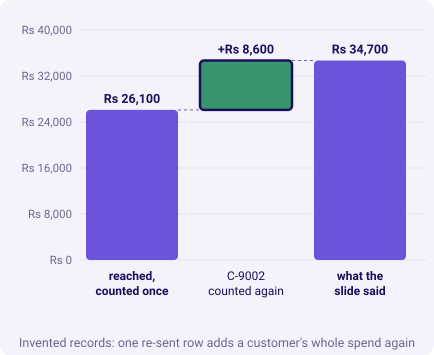

In [7]:
right_spend = int(small.loc[small["customer_id"].isin(small_feed["customer_id"]), "monetary"].sum())
kit.bridge(("reached, counted once", right_spend), [("C-9002 counted again", wrong_spend - right_spend)],
           end_label="what the slide said", lit=(0,),
           title="Invented records: one re-sent row adds a customer's whole spend again")
kit.check("the gap is exactly C-9002's spend", wrong_spend - right_spend == 8600)

**Your turn, on Kalpa's feed.** Type these three lines into the empty cell and read each
answer aloud before the next:

```python
exposure["customer_id"].duplicated().sum()
len(table), len(table.merge(exposure, on="customer_id", how="left"))
table.merge(exposure, on="customer_id", how="left", validate="one_to_one")
```

Then say, in one sentence to the marketing lead, what the naive merge would have done to the
spend of the customers the sale reached.

## 3. The fix: decide what one exposure means, then let validate guard it

A duplicate is a business question before it is a pandas one: a customer the sale reached
twice was still reached once. The rule for this table is **one row per customer, their
first exposure date**. Sort by date, keep the first row per customer, and merge with
`validate="one_to_one"` so a feed that breaks the rule next Monday stops the refresh.

In [8]:
first_touch = (exposure.sort_values("exposed_date")
                       .drop_duplicates("customer_id", keep="first")[["customer_id", "exposed_date"]])
with kit.expect_error() as clean:
    merged = table.merge(first_touch, on="customer_id", how="left", validate="one_to_one")
merged = merged.assign(exposed=merged["exposed_date"].notna())
kit.check("validate passes once the rule is applied", clean.name is None)
kit.check("the row count did not move: 340 in, 340 out", len(merged) == len(table) == 340)
kit.check("spend did not move: Rs 19,84,00,000 before and after",
          merged["monetary"].sum() == table["monetary"].sum(), kit.rupees(merged["monetary"].sum()))
kit.check("exposed customers equal the distinct customers in the feed",
          int(merged["exposed"].sum()) == exposure["customer_id"].nunique(), int(merged["exposed"].sum()))

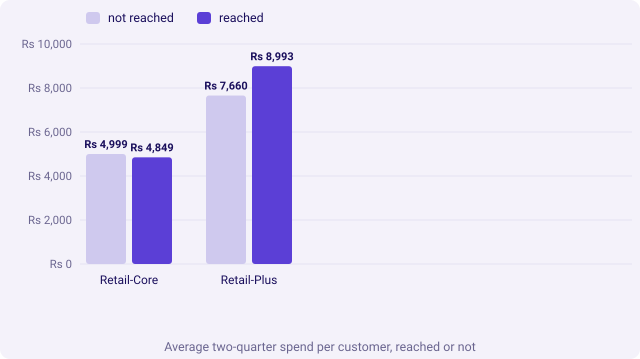

In [9]:
cons = merged[merged["segment"].isin(["Retail-Core", "Retail-Plus"])]
avg = cons.groupby(["segment", "exposed"])["monetary"].mean().unstack()
kit.columns(avg.index.tolist(), [("not reached", avg[False].round(0).tolist()),
                                 ("reached", avg[True].round(0).tolist())], fmt=kit.rupees,
            width=640, title="Average two-quarter spend per customer, reached or not")

**What the chart does not say.** Reached customers spent more on average in both segments.
Week 1 Thursday already showed why that is not the sale's effect: the platform targets
customers who were buying anyway. The table records exposure; it does not prove the sale
worked, and the marketing lead will hear that from Kavya if not from you.

## 4. The trap: groupby drops the customers with no segment

The marketing lead's second question: of the customers the sale reached, how many bought?
A hurried analyst starts from the feed, since those are the customers the question is about,
and attaches round 1's order totals, which carry the segment from the order rows.

**The plausible wrong answer.**

**Predict before you run.** What share of reached customers does the table say bought?
a) 82 percent; b) 100 percent; c) 50 percent; d) it cannot be computed.

In [10]:
buyers = (orders.merge(customers, on="customer_id", validate="many_to_one")
                .groupby("customer_id")
                .agg(segment=("segment", "first"), frequency=("order_id", "count"))
                .reset_index())
reach_wrong = buyers.merge(first_touch, on="customer_id", how="right", validate="one_to_one")
by_seg_wrong = reach_wrong.groupby("segment").agg(reached=("customer_id", "count"),
                                                  bought=("frequency", "count"))
kit.table(["segment", "reached", "bought", "share"],
          [(s, r.reached, r.bought, f"{r.bought / r.reached:.0%}") for s, r in by_seg_wrong.iterrows()],
          caption="What the slide would say")
kit.stats([(f"{by_seg_wrong['bought'].sum() / by_seg_wrong['reached'].sum():.0%}", "of reached customers bought",
            "the wrong table's headline"),
           (int(by_seg_wrong["reached"].sum()), "customers reached", "by the wrong table's count")])

segment,reached,bought,share
Retail-Core,56,56,100%
Retail-Plus,51,51,100%


**What happened.** The answer is b: 100 percent, on 107 customers reached. **Why it is
wrong.** The segment came from the order rows. A customer the sale reached who never ordered
has no order rows, so the right merge gives them a row with no segment, and `groupby` drops
a missing key by default (`dropna=True`). The customers who were reached and did not buy
are exactly the ones that vanished, so the table reports perfect conversion to a marketing
lead who is about to ask for the same budget again.

**The check that catches it.** The groups must add back to the rows. `dropna=False` shows
the missing group, and the sum of `reached` against the feed's distinct customers shows the
gap without looking at a single row.

In [11]:
shown = reach_wrong.groupby("segment", dropna=False)["customer_id"].count()
kit.table(["segment", "customers"], [("(missing)" if pd.isna(k) else k, v) for k, v in shown.items()],
          caption="The same groupby with dropna=False")
kit.check("the default groupby lost 23 reached customers",
          len(reach_wrong) - int(by_seg_wrong["reached"].sum()) == 23)
kit.check("the lost customers are exactly the reached customers with no orders",
          int(reach_wrong["segment"].isna().sum()) == int(reach_wrong["frequency"].isna().sum()) == 23)

segment,customers
Retail-Core,56
Retail-Plus,51
(missing),23


**The fix.** Take the segment from the customer list, which has one for every customer,
which means starting from `merged`, the validated table from section 3.

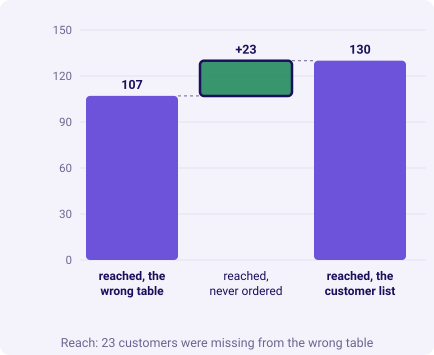

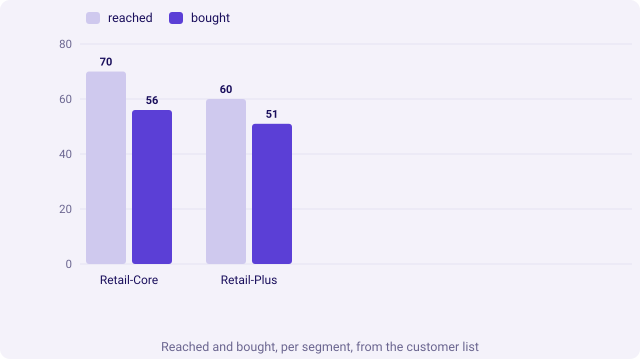

In [12]:
conv = merged[merged["exposed"]].groupby("segment").agg(
    reached=("customer_id", "count"), bought=("frequency", lambda s: int((s > 0).sum())))
kit.bridge(("reached, the wrong table", int(by_seg_wrong["reached"].sum())),
           [("reached, never ordered", int(conv["reached"].sum() - by_seg_wrong["reached"].sum()))],
           end_label="reached, the customer list", fmt=lambda v: f"{v:,.0f}", lit=(0,),
           title="Reach: 23 customers were missing from the wrong table")
kit.columns(conv.index.tolist(), [("reached", conv["reached"].tolist()), ("bought", conv["bought"].tolist())],
            width=640, title="Reached and bought, per segment, from the customer list")
share = conv["bought"].sum() / conv["reached"].sum()
kit.check("130 reached and 107 bought: 82 percent, where the wrong table said 100",
          conv["reached"].sum() == 130 and conv["bought"].sum() == 107, f"{share:.1%}")

> **Kavya's review.** "Two numbers moved in this round and neither raised an error on its
> own: spend that a re-sent row inflated, and reach that a missing key shrank. The row
> count before and after, and groups that add back to their rows, caught both. Put both
> checks in the refresh."

### In the interview

**[S] merge against join: what is the same and what differs?** "The same: both match rows
on a key, both come in inner, left, right and outer, and both multiply rows when a key
repeats on the side you did not expect. The differences: pandas defaults to inner, so I
always write `how=`; pandas runs in memory on data I already pulled, where the warehouse
joins where the data lives; and pandas can refuse the wrong shape with `validate=`, which
SQL has no single argument for."

**[F] Which merge argument raises on duplicate keys, and which error?** "`validate`, with
`one_to_one`, `one_to_many` or `many_to_one`. When the keys break the promise it raises
`pandas.errors.MergeError`, saying which side's keys are not unique. It is the row-count
check made loud: it stops the table being built instead of reporting after the fact."

**Follow-up: your merge raised MergeError on Monday's refresh. What do you do?** "I do not
drop duplicates to make it pass. I look at the duplicated keys, find out why the source
sent them, and apply a business rule, here first exposure per customer, then keep
`validate` so the next surprise also stops the run."

**Follow-up: why did your groupby lose customers?** "`groupby` drops missing keys by
default. I check that the groups add back to the rows, and I pass `dropna=False` when a
missing group is information."

### Depth: `indicator=True`, the anti-join in pandas

Tuesday's anti-join, rows on one side with no match on the other, is one argument in pandas:
`indicator=True` adds a `_merge` column saying where each row came from.

In [13]:
both = table.merge(first_touch, on="customer_id", how="left", indicator=True, validate="one_to_one")
counts = both["_merge"].value_counts()
kit.table(["_merge", "customers", "reads as"],
          [("both", int(counts.get("both", 0)), "the sale reached them"),
           ("left_only", int(counts.get("left_only", 0)), "on the customer list, never reached"),
           ("right_only", int(counts.get("right_only", 0)), "in the feed, unknown to the customer list")],
          caption="indicator=True on the customer list against the first-touch feed")
kit.check("no customer in the feed is unknown to the warehouse", int(counts.get("right_only", 0)) == 0)

_merge,customers,reads as
both,130,the sale reached them
left_only,210,"on the customer list, never reached"
right_only,0,"in the feed, unknown to the customer list"


What this round established,The evidence
"merge is a join, and its default is inner",the unreached disappear without how='left'
a repeated key multiplies rows and money,"invented: Rs 26,100 became Rs 34,700"
validate= turns the count check into a MergeError,raised before a wrong table existed
a duplicate needs a business rule,"first exposure per customer: 340 rows, spend unchanged"
groupby drops missing keys by default,"reach 107 at 100 percent, truly 130 at 82 percent"


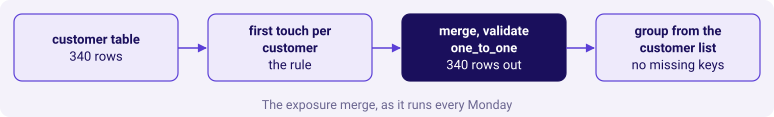

Next: round 3 turns the orders into a months view, and meets pivot_table's default.


In [14]:
kit.table(["What this round established", "The evidence"],
          [("merge is a join, and its default is inner", "the unreached disappear without how='left'"),
           ("a repeated key multiplies rows and money", "invented: Rs 26,100 became Rs 34,700"),
           ("validate= turns the count check into a MergeError", "raised before a wrong table existed"),
           ("a duplicate needs a business rule", "first exposure per customer: 340 rows, spend unchanged"),
           ("groupby drops missing keys by default", "reach 107 at 100 percent, truly 130 at 82 percent")],
          caption="Round 2")
kit.flow(["customer table\n340 rows", "first touch per customer\nthe rule",
          "merge, validate one_to_one\n340 rows out", "group from the customer list\nno missing keys"],
         lit=2, title="The exposure merge, as it runs every Monday")
kit.check_summary()
print("Next: round 3 turns the orders into a months view, and meets pivot_table's default.")